In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import HTML, display

# from core.config_loader import MIN_BIN, MAX_BIN, MIN_BIN_SIZE, MAX_BIN_SIZE, MIN_DIFF_WOE, SPECIALVALUE
from core.woe_stats import create_woe_df, get_bin_stats
# from woe_all.optimization import calculate_feature
from woe_all.plotting import plot_options
from woe_all.html_tables import display_woe_tables
from optbinning import OptimalBinning

%matplotlib inline


In [44]:
MIN_BIN = 4
MAX_BIN = 10
MIN_BIN_SIZE = 0.05
MAX_BIN_SIZE = 0.5
MIN_DIFF_WOE = 0.01
SPECIALVALUE = 0
OPTIONS = {
    "1. Free optimization": "auto",
    "2. Monotonic": "auto_asc_desc",
    "3. U-shape / heuristic": "auto_heuristic",
}

## Hàm hỗ trợ

In [45]:
class _InfeasibleModel:
    def __init__(self):
        self.status = "INFEASIBLE"
        self.splits = []
        self.binning_table = None


def calculate_feature(feature, X_train, y, considerMISSING=False):
    x_original = X_train[feature].copy()

    zero_pct = (x_original == SPECIALVALUE).mean()

    special_allowed = zero_pct >= MIN_BIN_SIZE
    if special_allowed:
        mask_nonmissing = x_original.notna() & (x_original != SPECIALVALUE)
    else:
        mask_nonmissing = x_original.notna()

    x = x_original.loc[mask_nonmissing]
    y_clean = y.loc[mask_nonmissing]

    n_old = len(X_train)
    n_new = len(x)

    if n_new == 0:
        raise ValueError("Feature has no usable observations.")

    if considerMISSING:
        min_bin_size = MIN_BIN_SIZE * n_old / n_new
        max_bin_size = min(MAX_BIN_SIZE * n_old / n_new, 1)
    else:
        min_bin_size = MIN_BIN_SIZE
        max_bin_size = MAX_BIN_SIZE

    infeasible = considerMISSING and min_bin_size > 0.5

    p_bar = np.mean(y_clean)
    min_event_rate_diff = 2 * p_bar * (1 - p_bar) * np.tanh(MIN_DIFF_WOE / 2)

    part = "considerMISSING" if considerMISSING else "removeMISSING"

    results = {}

    for option_name, trend in OPTIONS.items():
        if infeasible:
            optb = _InfeasibleModel()
        else:
            optb = OptimalBinning(name=feature, dtype="numerical", min_n_bins=MIN_BIN, max_n_bins=MAX_BIN, min_bin_size=min_bin_size, max_bin_size=max_bin_size, min_event_rate_diff=min_event_rate_diff, monotonic_trend=trend)
            optb.fit(x, y_clean)

        missing_first = considerMISSING and optb.status == "OPTIMAL"
        if special_allowed:
            if considerMISSING:
                display_x = x_original
                display_y = y
            else:
                display_x = x_original[x_original.notna()]
                display_y = y.loc[display_x.index]
        elif missing_first:
            display_x = x_original
            display_y = y
        else:
            display_x = x
            display_y = y_clean

        results[f"{part} | {option_name}"] = {
            "part": part,
            "option": option_name,
            "model": optb,
            "splits": optb.splits,
            "binning_table": optb.binning_table,
            "x": display_x,
            "y": display_y,
            "missing_first": missing_first,
            "specialvalue": SPECIALVALUE if special_allowed else None,
        }

    return results

In [46]:
def validate_splits(x, splits, min_n_bins, max_n_bins, min_bin_size, max_bin_size, missing_first=False, specialvalue=None):
    """
    Validate manually edited split points.
    """

    splits = np.array(splits, dtype=float)

    # Check finite
    if not np.all(np.isfinite(splits)):
        return {'valid': False, 'message': 'Edited splits phải là các số finite.'}
    # Sort
    splits = np.sort(splits)
    # Check duplicate
    if len(np.unique(splits)) != len(splits):
        return {'valid': False, 'message': 'Edited splits chứa duplicate split point.'}

    n_bins = len(splits) + 1

    if n_bins < min_n_bins:
        return {
            'valid': False,
            'message': (
                f'Số bin = {n_bins}, nhỏ hơn min_n_bins = '
                f'{min_n_bins}.'
            )
        }

    if n_bins > max_n_bins:
        return {
            'valid': False,
            'message': (
                f'Số bin = {n_bins}, lớn hơn max_n_bins = '
                f'{max_n_bins}.'
            )
        }

    bin_stats = get_bin_stats(
        x=x,
        y=pd.Series(index=x.index, data=0),
        splits=splits,
        missing_first=missing_first,
        specialvalue=specialvalue,
    )

    numeric_stats = bin_stats[~bin_stats['bin'].astype(str).str.startswith(('Missing', 'Special'))].copy()
    min_violation = numeric_stats[numeric_stats['prob_n_obs'] < min_bin_size].copy()
    max_violation = numeric_stats[numeric_stats['prob_n_obs'] > max_bin_size].copy()

    valid = (len(min_violation) == 0 and len(max_violation) == 0)

    return {
        'valid': valid,
        'n_bins': n_bins,
        'splits': splits,
        'bin_stats': bin_stats,
        'min_violation': min_violation,
        'max_violation': max_violation,
        'message': (
            'Edited splits hợp lệ.' if valid else 'Edited splits vi phạm bin-size constraint.'
        )
    }


In [47]:
def plot_raw_woe(x, y, feature='', n_bins=50, specialvalue=0, smoothing=0.5, splits_ref=None):
    data = pd.DataFrame({'x': pd.to_numeric(x, errors='coerce'), 'target': y}).copy()
    data = data[data['target'].isin([0, 1])].copy()
    if data.empty:
        return

    missing = data['x'].isna()
    special = data['x'].eq(specialvalue) if specialvalue is not None else pd.Series(False, index=data.index)
    numeric = ~(missing | special)
    x_numeric = data.loc[numeric, 'x']

    n_unique_num = x_numeric.nunique()

    if n_unique_num == 0:
        numeric_bins = pd.Series(pd.NA, index=data.index, dtype='object')
        bin_labels = []
    elif n_unique_num <= n_bins:
        values = np.sort(x_numeric.unique())
        numeric_bins = data['x'].map({v: str(v) for v in values}).where(numeric)
        bin_labels = [str(v) for v in values]
    else:
        quantiles = np.linspace(0, 1, n_bins + 1)
        edges = np.unique(x_numeric.quantile(quantiles).to_numpy())
        if len(edges) < 2:
            numeric_bins = data['x'].map({x_numeric.iloc[0]: str(x_numeric.iloc[0])}).where(numeric)
            bin_labels = [str(x_numeric.iloc[0])]
        else:
            numeric_bins = pd.cut(data['x'], bins=edges, include_lowest=True, right=True)
            bin_labels = [str(v) for v in numeric_bins.dropna().unique()]
            bin_labels = sorted(bin_labels, key=lambda z: float(z.split(',')[0].strip('([')))

    data['_bin_'] = numeric_bins.astype(object)
    data.loc[missing, '_bin_'] = 'MISSING'
    data.loc[special, '_bin_'] = 'ZERO'

    grouped = data.groupby('_bin_', dropna=False)['target'].agg(
        n_obs='count',
        n_card='sum'
    ).reset_index()

    grouped['n_non_card'] = grouped['n_obs'] - grouped['n_card']

    total_card = grouped['n_card'].sum()
    total_non_card = grouped['n_non_card'].sum()
    n_categories = len(grouped)

    grouped['pct_card'] = grouped['n_card'] / total_card if total_card > 0 else 0
    grouped['pct_non_card'] = grouped['n_non_card'] / total_non_card if total_non_card > 0 else 0

    grouped['pct_card_smooth'] = (grouped['n_card'] + smoothing) / (total_card + smoothing * n_categories)
    grouped['pct_non_card_smooth'] = (grouped['n_non_card'] + smoothing) / (total_non_card + smoothing * n_categories)
    grouped['WOE'] = np.log(grouped['pct_card_smooth'] / grouped['pct_non_card_smooth'])
    grouped['pct_obs'] = grouped['n_obs'] / len(data)

    def sort_key(value):
        if value == 'MISSING':
            return (-2, 0.0)
        if value == 'ZERO':
            return (-1, 0.0)
        try:
            if isinstance(value, str) and value.startswith(('(', '[')):
                left = value.split(',')[0].strip('([')
                return (0, float(left))
            return (0, float(value))
        except (ValueError, TypeError):
            return (1, 0.0)

    grouped['_sort'] = grouped['_bin_'].apply(sort_key)
    grouped = grouped.sort_values('_sort').reset_index(drop=True).drop(columns='_sort')

    x_pos = np.arange(len(grouped))
    labels = grouped['_bin_'].astype(str).tolist()
    missing_mask = grouped['_bin_'].eq('MISSING')
    zero_mask = grouped['_bin_'].eq('ZERO')

    fig, ax_woe = plt.subplots(figsize=(15, 6))
    ax_obs = ax_woe.twinx()

    ax_obs.bar(x_pos, grouped['pct_obs'], width=0.85, color='#5B9BD5', alpha=0.28, label='% Obs', zorder=1)
    ax_woe.plot(x_pos, grouped['WOE'], color='green', marker='o', markersize=4, linewidth=1.3, linestyle='--', label='WOE', zorder=3)

    if missing_mask.any():
        ax_woe.scatter(x_pos[missing_mask], grouped.loc[missing_mask, 'WOE'], color='red', s=45, zorder=4)

    if zero_mask.any():
        ax_woe.scatter(x_pos[zero_mask], grouped.loc[zero_mask, 'WOE'], color='orange', s=45, zorder=4)

    ax_woe.axhline(0, color='red', linestyle=':', linewidth=1)
    ax_woe.set_ylabel('WOE', color='green')
    ax_woe.tick_params(axis='y', labelcolor='green')
    ax_obs.set_ylabel('% Observations', color='#5B9BD5')
    ax_obs.tick_params(axis='y', labelcolor='#5B9BD5')
    ax_obs.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.3f}'))

    if splits_ref is not None and n_unique_num > n_bins and len(x_numeric) > 0:
        for split in splits_ref:
            if x_numeric.min() < split < x_numeric.max():
                idx = np.searchsorted(x_numeric.quantile(np.linspace(0, 1, n_bins + 1)).to_numpy(), split, side='right') - 1
                idx = max(0, min(idx, len(x_pos) - 1))
                ax_woe.axvline(idx, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)

    ax_woe.set_xticks(x_pos)
    ax_woe.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax_woe.set_xlabel(feature)
    ax_woe.set_title(f'Weight of Evidence by {feature} (n_categories={len(grouped)})')
    ax_woe.grid(axis='y', alpha=0.15)

    handles_woe, labels_woe = ax_woe.get_legend_handles_labels()
    handles_obs, labels_obs = ax_obs.get_legend_handles_labels()
    ax_woe.legend(handles_woe + handles_obs, labels_woe + labels_obs, loc='upper left')

    plt.tight_layout()
    plt.show()

In [48]:
def plot_woe_onsplits(df, x, y, splits, feature='', missing_first=False, specialvalue=None, ax=None):
    bin_stats = get_bin_stats(x=x, y=y, splits=splits, missing_first=missing_first, specialvalue=specialvalue)

    # Nếu truyền ax từ ngoài vào thì vẽ lên ax đó, ngược lại mới tạo fig/ax mới
    if ax is None:
        fig, ax_woe = plt.subplots(figsize=(7, 4))
    else:
        ax_woe = ax
        fig = ax_woe.get_figure()

    x_pos = np.arange(len(df))

    ax_woe.plot(x_pos, df['WOE'], marker='o', linewidth=2, label='WOE')
    ax_woe.axhline(0, linestyle='--', linewidth=1)

    ax_woe.set_xlabel('Bin')
    ax_woe.set_ylabel('WOE')
    ax_woe.set_xticks(x_pos)
    ax_woe.set_xticklabels(df['Bin'], rotation=30, ha='right')
    ax_woe.grid(axis='y', alpha=0.3)

    ax_count = ax_woe.twinx()
    ax_count.bar(x_pos, bin_stats['n_obs'], alpha=0.25, width=0.6, label='Bin Count')

    ax_count.set_ylabel('Bin Count')
    ax_woe.set_title(f'{feature}')

    handles_woe, labels_woe = ax_woe.get_legend_handles_labels()
    handles_count, labels_count = ax_count.get_legend_handles_labels()

    ax_woe.legend(handles_woe + handles_count, labels_woe + labels_count, loc='best')

    return fig

In [49]:


def _woe_trend(woe):
    woe = pd.to_numeric(woe, errors='coerce').dropna().to_numpy()

    if len(woe) < 3:
        return 'no_clear_trend'

    diff = np.diff(woe)
    diff = diff[diff != 0]

    if len(diff) == 0:
        return 'no_clear_trend'

    signs = np.sign(diff)

    if np.all(signs > 0) or np.all(signs < 0):
        return 'monotonic'

    changes = np.where(signs[1:] != signs[:-1])[0]

    if len(changes) == 1:
        i = changes[0]

        if signs[i] < 0 and signs[i + 1] > 0:
            return 'u_shape'

        if signs[i] > 0 and signs[i + 1] < 0:
            return 'inverted_u_shape'

    return 'no_clear_trend'


def compare_woe_tables(old_df,new_df,thresholds=(0.5,0.3,0.1,0.02)):
    old = old_df.copy().reset_index(drop=True)
    new = new_df.copy().reset_index(drop=True)

    old_iv_total = old['IV_total'].iloc[0]
    new_iv_total = new['IV_total'].iloc[0]
    iv_total_gap = new_iv_total - old_iv_total

    if iv_total_gap > 0:
        iv_total_direction = 'increased'
    elif iv_total_gap < 0:
        iv_total_direction = 'decreased'
    else:
        iv_total_direction = 'unchanged'

    old_trend = _woe_trend(old['WOE'])
    new_trend = _woe_trend(new['WOE'])

    trend_summary = pd.DataFrame({
        'table': ['old', 'edit'],
        'WOE_trend': [old_trend, new_trend]
    })

    if len(old) != len(new):
        raise ValueError(
            f'Old and edit must have the same number of bins: '
            f'old={len(old)}, edit={len(new)}'
        )

    iv_comparison = pd.DataFrame({
        'bin_order': np.arange(1,len(old) + 1),
        'Bin_old': old['Bin'],
        'Bin_new': new['Bin'],
        'IV_old': old['IV_detail'],
        'IV_new': new['IV_detail']
    })

    iv_comparison['gap'] = iv_comparison['IV_new'] - iv_comparison['IV_old']
    # iv_comparison['abs_gap'] = iv_comparison['gap'].abs()

    def _get_threshold_range(iv, thresholds):
        """
        Xác định khoảng threshold mà IV thuộc vào.

        thresholds được hiểu là các mốc giảm dần, ví dụ:
        (0.5, 0.3, 0.1, 0.02)
        """

        thresholds = sorted(thresholds, reverse=True)

        for i, threshold in enumerate(thresholds):
            if iv >= threshold:
                if i == 0:
                    return f">= {threshold:.2f}"
                else:
                    upper = thresholds[i - 1]
                    return f"[{threshold:.2f}, {upper:.2f})"

        return f"< {thresholds[-1]:.2f}"


    threshold_changes = []

    for _, row in iv_comparison.iterrows():

        old_iv = row['IV_old']
        new_iv = row['IV_new']

        old_range = _get_threshold_range(old_iv, thresholds)
        new_range = _get_threshold_range(new_iv, thresholds)

        threshold_changed = old_range != new_range

        threshold_changes.append({
            'bin_order': row['bin_order'],
            'Bin_old': row['Bin_old'],
            'Bin_new': row['Bin_new'],
            'IV_old': old_iv,
            'IV_new': new_iv,
            'gap': row['gap'],
            'threshold_old': old_range,
            'threshold_new': new_range,
            'threshold_changed': threshold_changed
        })

    threshold_changes = pd.DataFrame(threshold_changes)

    return {
        'iv_total': {
            'old': old_iv_total,
            'edit': new_iv_total,
            'gap': iv_total_gap,
            'abs_gap': abs(iv_total_gap),
            'direction': iv_total_direction
        },
        'woe_trend': trend_summary,
        'iv_bin_comparison': iv_comparison,
        'threshold_changes': threshold_changes
    }

In [50]:
def check_valid_bins(validation, min_bin_size, max_bin_size, min_n_bins, max_n_bins):
    if not validation['valid']:
        print("Result: Edited splits không hợp lệ.")

        if validation.get('n_bins', 0) < min_n_bins:
            print(f"- Số bin = {validation['n_bins']}, nhỏ hơn min_n_bins = {min_n_bins}.")
        elif validation.get('n_bins', 0) > max_n_bins:
            print(f"- Số bin = {validation['n_bins']}, lớn hơn max_n_bins = {max_n_bins}.")

        min_violation = validation.get('min_violation', pd.DataFrame())
        if not min_violation.empty:
            print(f"- Các bin có prob_n_obs < min_bin_size ({min_bin_size:.2%}):")
            display(min_violation.style.format({'prob_n_obs': '{:.2%}'}))

        max_violation = validation.get('max_violation', pd.DataFrame())
        if not max_violation.empty:
            print(f"- Các bin có prob_n_obs > max_bin_size ({max_bin_size:.2%}):")
            display(max_violation.style.format({'prob_n_obs': '{:.2%}'}))

        raise ValueError("Hãy chỉnh lại edited_splits.")


In [51]:
def comment_woe_trend(trend):
    old_trend = trend.loc[trend['table'] == 'old', 'WOE_trend'].iloc[0]
    edit_trend = trend.loc[trend['table'] == 'edit', 'WOE_trend'].iloc[0]

    print(f"WOE trend gốc : {old_trend}")
    print(f"WOE trend mới : {edit_trend}")

    if old_trend == edit_trend:
        print(f"WOE trend không thay đổi: cả cũ và edit đều là {old_trend}.")
    else:
        print(f"WOE trend thay đổi: {old_trend} -> {edit_trend}.")

In [52]:
def comment_iv_total(iv):
    print(f"IV total gốc : {iv['old']:.6f}")
    print(f"IV total mới : {iv['edit']:.6f}")
    if iv['direction'] == 'increased':
        print(f"IV total mới TĂNG {iv['abs_gap']:.6f} so với cũ.")
    elif iv['direction'] == 'decreased':
        print(f"IV total mới GIẢM {iv['abs_gap']:.6f} so với cũ.")
    else:
        print("IV total mới KHÔNG THAY ĐỔI so với cũ.")

In [53]:
def display_threshold_changes(result):
    df = result['threshold_changes'].copy()

    def highlight_changed(row):
        if row['threshold_changed']:
            return ['background-color: #FFF2CC'] * len(row)
        return [''] * len(row)

    return (
        df.style
        .apply(highlight_changed, axis=1)
        .format({
            'IV_old': '{:.4f}',
            'IV_new': '{:.4f}',
            'gap': '{:+.4f}'
        })
    )

In [54]:
def display_grouped_woe_tables(html_code):
    blocks = html_code.split('<div class="woe-block">')[1:]
    groups = {"removeMISSING": [], "considerMISSING": []}

    for block in blocks:
        for group in groups:
            if group in block:
                groups[group].append('<div class="woe-block">' + block)
                break

    grouped_html = f"""
    <style>
    .woe-group {{ margin-bottom: 20px; }}
    .woe-group-title {{ font-size: 14px; font-weight: bold; margin-bottom: 5px; }}
    .woe-group-row {{ display: flex; gap: 20px; align-items: flex-start; }}
    .woe-group-row .woe-block {{ flex: 1; min-width: 1; }}
    .woe-group-row table {{ width: 100%; font-size: 10px;}}
    </style>
    <div class="woe-group">
        <div class="woe-group-title">removeMISSING</div>
        <div class="woe-group-row">{''.join(groups["removeMISSING"])}</div>
    </div>
    <div class="woe-group">
        <div class="woe-group-title">considerMISSING</div>
        <div class="woe-group-row">{''.join(groups["considerMISSING"])}</div>
    </div>
    """
    return grouped_html

## Đọc file csv

In [55]:
df = pd.read_csv('train_sdf_selected1.csv')

X_train = df.drop(columns=['LABEL'])
y = pd.Series(df['LABEL'].values, index=X_train.index)
print('Data features:')
df.columns

Data features:


Index(['A', 'B', 'C', 'D', 'LABEL'], dtype='str')

## Chọn biến cần tính

In [56]:
feature = "A"

In [57]:
x = X_train[feature].copy()

### Tính lại min, max bin size
Vì drop missing và ZERO nên tỉ lệ ràng buộc 5% < x < 50% sẽ thay đổi

In [58]:
specialvalue = SPECIALVALUE

# Calculate proportion of zero values
zero_pct = (x == specialvalue).mean()

if zero_pct < MIN_BIN_SIZE:
    print('Not split zero')
    mask_nonmissing = x.notna()
else:
    print('Split zero')
    mask_nonmissing = x.notna() & (x != specialvalue)

x = x.loc[mask_nonmissing]
y_clean = y.loc[mask_nonmissing]

n_old = len(X_train)
n_missing = X_train[feature].isna().sum()
n_zero = int((X_train[feature] == specialvalue).sum())
n_new = len(x)


Not split zero


In [59]:
print('Original observations:', n_old)
print(f'Missing: {n_missing/n_old*100:.2f}%')
print('Zero:', n_zero)
print('Clean observations:', n_new)

print('Min bin size (removeMISSING):', MIN_BIN_SIZE)
print('Max bin size (removeMISSING):', MAX_BIN_SIZE)

min_bin_size_missing = MIN_BIN_SIZE * n_old / n_new
max_bin_size_missing = min(MAX_BIN_SIZE * n_old / n_new, 0.5)
print('Min bin size (considerMISSING):', min_bin_size_missing)
print('Max bin size (considerMISSING):', max_bin_size_missing)


Original observations: 64343
Missing: 67.52%
Zero: 0
Clean observations: 20900
Min bin size (removeMISSING): 0.05
Max bin size (removeMISSING): 0.5
Min bin size (considerMISSING): 0.1539306220095694
Max bin size (considerMISSING): 0.5


## 3 tùy chọn tính WOE

In [60]:
results = {}
for consider in (False, True):
    results.update(calculate_feature(feature, X_train, y, considerMISSING=consider))

print('Total options:', len(results))
for option_name in results:
    print(' -', option_name)


Total options: 6
 - removeMISSING | 1. Free optimization
 - removeMISSING | 2. Monotonic
 - removeMISSING | 3. U-shape / heuristic
 - considerMISSING | 1. Free optimization
 - considerMISSING | 2. Monotonic
 - considerMISSING | 3. U-shape / heuristic


Tăng `min_diff_woe` nếu muốn tăng độ khác biệt WOE giữa 2 bins

In [61]:
print('min_diff_woe (config):', MIN_DIFF_WOE)


min_diff_woe (config): 0.01


### Trạng thái giải xu hướng WOE 
OPTIMAL - Giải thành công \
INFEASIBLE - Không giải được

In [62]:
print('OPTIMAL SPLITS')

for option_name, result in results.items():
    print(f'\n{option_name}')
    print('Part:', result['part'])
    print('Status:', result['model'].status)
    print('Optimal splits:', list(map(float, result['splits'])))
    print('Missing first:', result['missing_first'])


OPTIMAL SPLITS

removeMISSING | 1. Free optimization
Part: removeMISSING
Status: OPTIMAL
Optimal splits: [1.5, 3.5, 10.5, 57.5, 83.5, 210.5]
Missing first: False

removeMISSING | 2. Monotonic
Part: removeMISSING
Status: OPTIMAL
Optimal splits: [10.5, 57.5, 83.5, 210.5]
Missing first: False

removeMISSING | 3. U-shape / heuristic
Part: removeMISSING
Status: OPTIMAL
Optimal splits: [1.5, 3.5, 10.5, 57.5, 83.5, 210.5]
Missing first: False

considerMISSING | 1. Free optimization
Part: considerMISSING
Status: OPTIMAL
Optimal splits: [3.5, 10.5, 57.5]
Missing first: True

considerMISSING | 2. Monotonic
Part: considerMISSING
Status: OPTIMAL
Optimal splits: [10.5, 38.5, 83.5]
Missing first: True

considerMISSING | 3. U-shape / heuristic
Part: considerMISSING
Status: OPTIMAL
Optimal splits: [3.5, 10.5, 57.5]
Missing first: True


### Biểu đồ WOE ở 3 configs

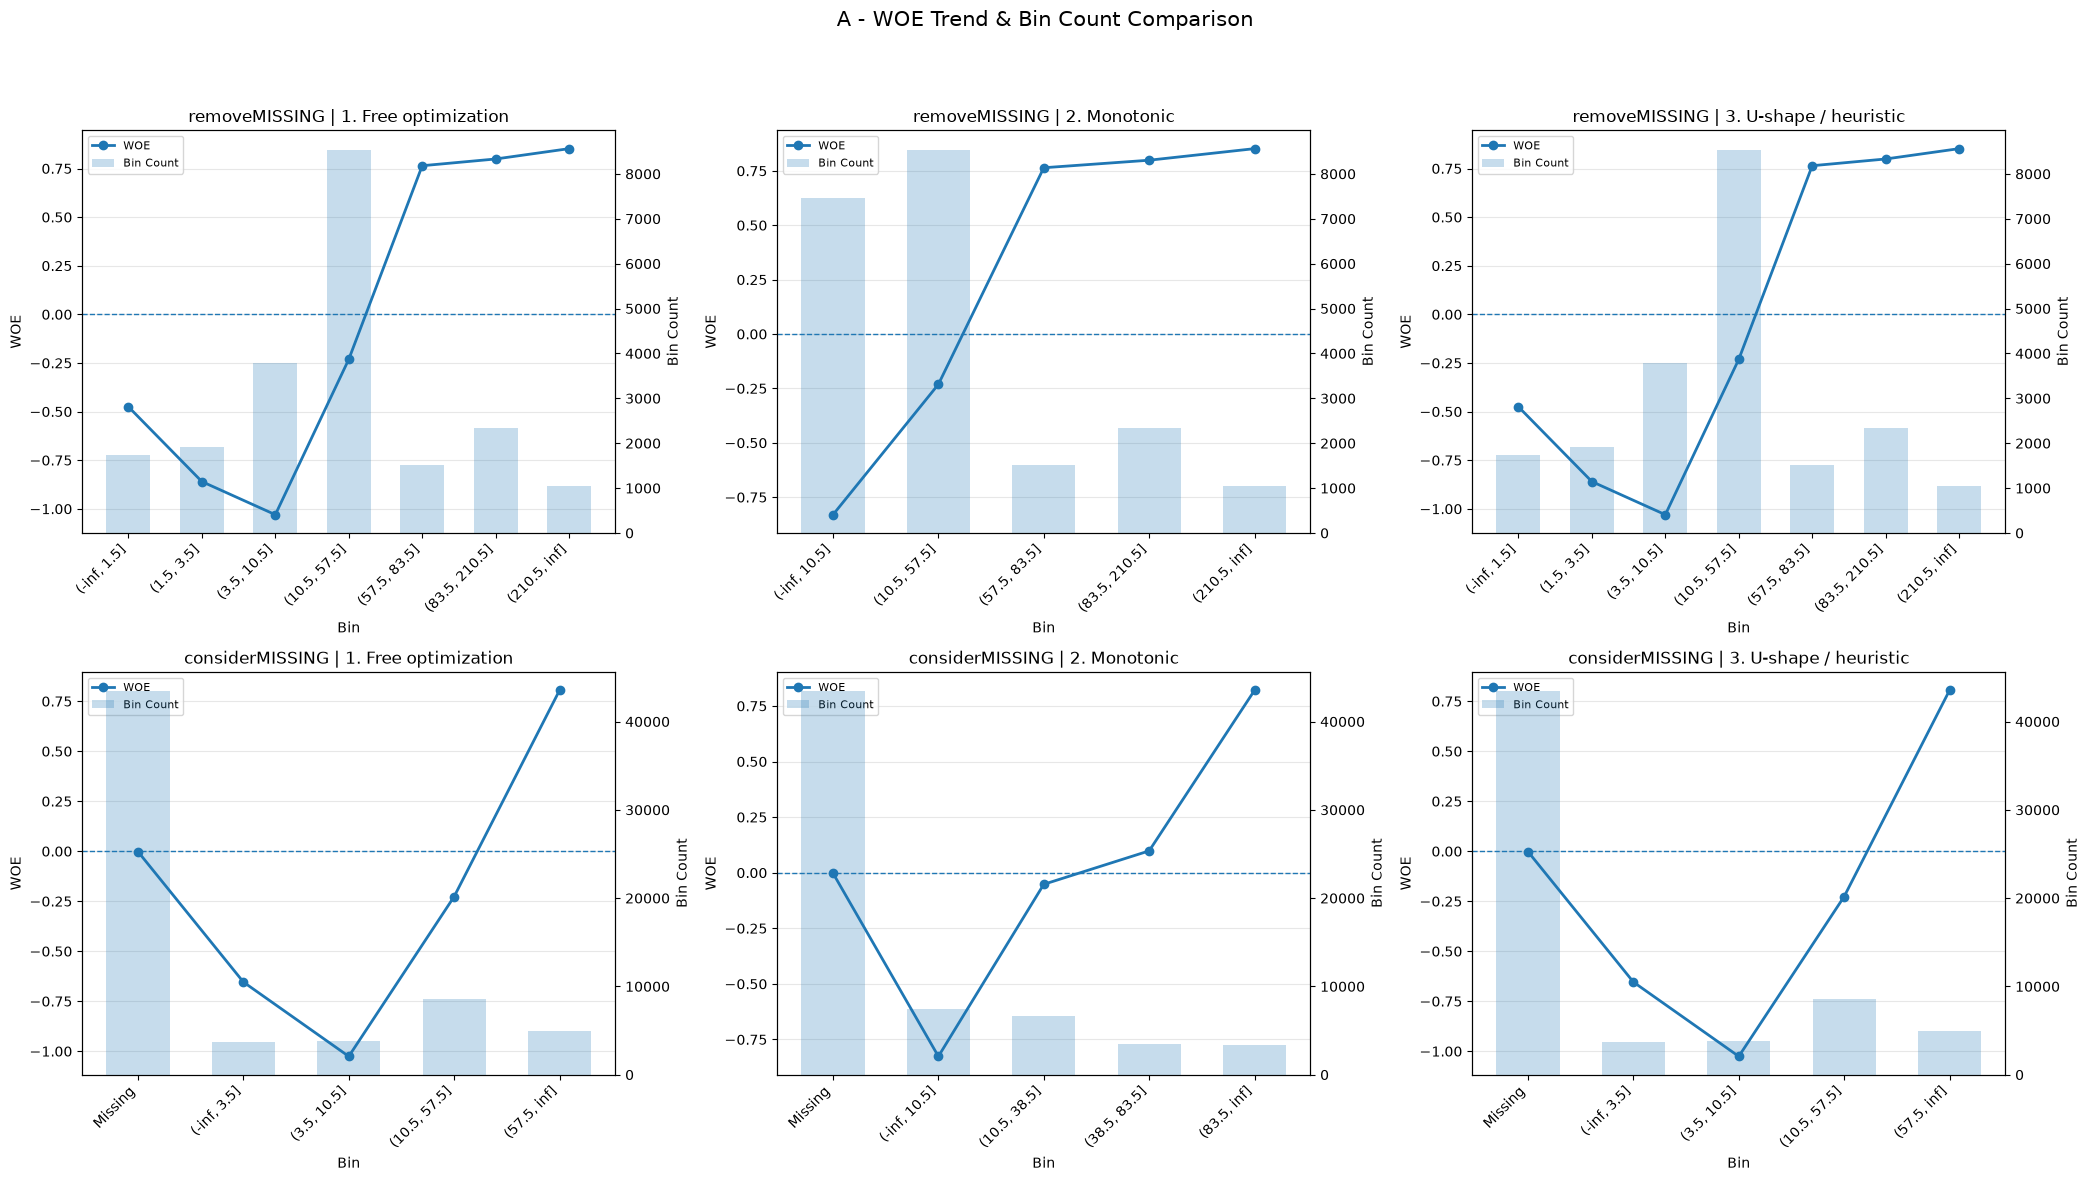

In [63]:
plot_options(results, feature)


### Bảng thông tin WOE và IV

In [64]:
woe_tables, html_code = display_woe_tables(
    results=results, create_woe_df_func=create_woe_df, render=False
)
grouped_html = display_grouped_woe_tables(html_code)
display(HTML(grouped_html))

WOE TABLES


In [65]:
print('Các option đã tính:')
for option_name in woe_tables:
    print(' -', option_name)


Các option đã tính:
 - removeMISSING | 1. Free optimization
 - removeMISSING | 2. Monotonic
 - removeMISSING | 3. U-shape / heuristic
 - considerMISSING | 1. Free optimization
 - considerMISSING | 2. Monotonic
 - considerMISSING | 3. U-shape / heuristic


## Tùy chỉnh khoảng bin 
Comment/uncomment để chọn option

In [66]:
# chosen_option = 'removeMISSING | 1. Free optimization'
# chosen_option = 'removeMISSING | 2. Monotonic'
# chosen_option = 'removeMISSING | 3. U-shape / heuristic'
# chosen_option = 'considerMISSING | 1. Free optimization'
chosen_option = 'considerMISSING | 2. Monotonic'
# chosen_option = 'considerMISSING | 3. U-shape / heuristic'

result = results[chosen_option]
chosensplit = [float(s) for s in result['splits']]

display_x = result['x']
display_y = result['y']
missing_first = result['missing_first']
specialvalue = result['specialvalue']

if result['part'] == 'considerMISSING':
    min_bin_size = MIN_BIN_SIZE * n_old / n_new
    max_bin_size = min(MAX_BIN_SIZE * n_old / n_new, 1)
else:
    min_bin_size = MIN_BIN_SIZE
    max_bin_size = MAX_BIN_SIZE

print('Chosen option:', chosen_option)
print('Chosen splits:', chosensplit)
print('min_bin_size:', min_bin_size)
print('max_bin_size:', max_bin_size)
print('missing_first:', missing_first)
print('specialvalue:', specialvalue)


Chosen option: considerMISSING | 2. Monotonic
Chosen splits: [10.5, 38.5, 83.5]
min_bin_size: 0.1539306220095694
max_bin_size: 1
missing_first: True
specialvalue: None


Khoảng chia bin gốc được chọn

In [67]:
print(chosensplit)


[10.5, 38.5, 83.5]


Copy bin gốc phía trên và Chỉnh sửa bin

In [68]:
edited_splits = [10.5, 38.5, 83.5]

Kiểm tra bin mới có hợp lệ hay không? Nếu không thỏa điều kiện, sẽ raise lỗi

In [69]:
validation = validate_splits(
    x=x,
    splits=edited_splits,
    min_n_bins=MIN_BIN,
    max_n_bins=MAX_BIN,
    min_bin_size=min_bin_size,
    max_bin_size=max_bin_size,
)

print(f"Edited splits: {edited_splits}")
print(f"Number of bins: {validation.get('n_bins')}")

check_valid_bins(
    validation,
    min_bin_size=min_bin_size,
    max_bin_size=max_bin_size,
    min_n_bins=MIN_BIN,
    max_n_bins=MAX_BIN,
)

print("Result: Edited splits hợp lệ.")
splits = validation['splits']
print(f"Valid edited splits: {list(map(float, splits))}")


Edited splits: [10.5, 38.5, 83.5]
Number of bins: 4
Result: Edited splits hợp lệ.
Valid edited splits: [10.5, 38.5, 83.5]


### So sánh và đánh giá giữa bins gốc và mới

#### Kết quả gốc

In [70]:
old_woe_df = create_woe_df(display_x, display_y, chosensplit, missing_first=missing_first, specialvalue=specialvalue)
edited_woe_df = create_woe_df(display_x, display_y, splits, missing_first=missing_first, specialvalue=specialvalue)


#### Kết quả mới

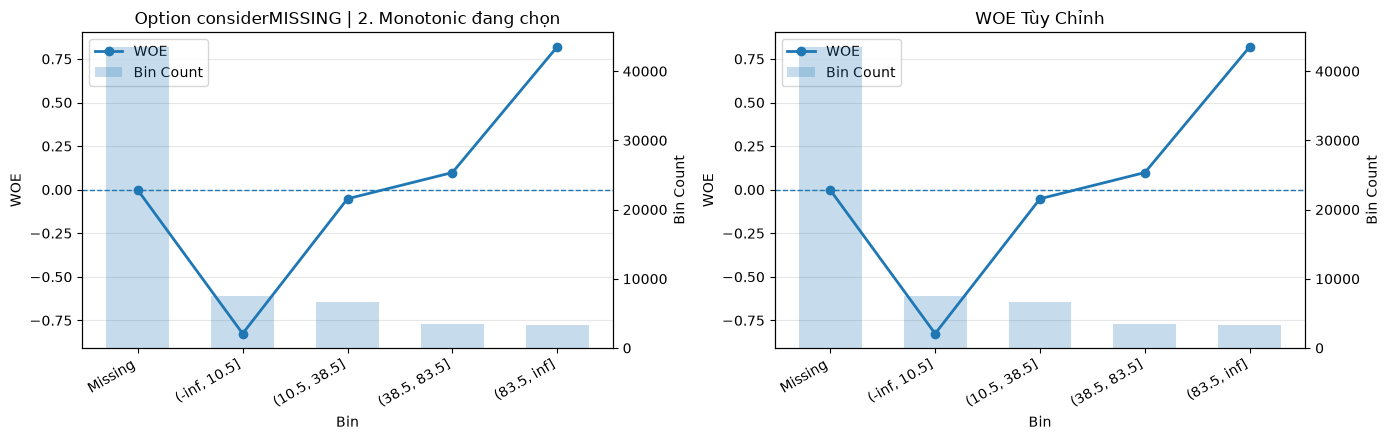

,Bin,prob_n_obs,pct_event,pct_non_event,WOE,IV_detail,IV_total
0,Missing,67.52%,0.673729,0.675184,-0.0022,0.0000,0.1092
1,"(-inf, 10.5]",11.59%,0.050847,0.116134,-0.8259,0.0539,0.1092
2,"(10.5, 38.5]",10.27%,0.097458,0.102672,-0.0521,0.0003,0.1092
3,"(38.5, 83.5]",5.38%,0.059322,0.053769,0.0983,0.0005,0.1092
4,"(83.5, inf]",5.25%,0.118644,0.052241,0.8203,0.0545,0.1092
,Bin,prob_n_obs,pct_event,pct_non_event,WOE,IV_detail,IV_total
0,Missing,67.52%,0.673729,0.675184,-0.0022,0.0000,0.1092
1,"(-inf, 10.5]",11.59%,0.050847,0.116134,-0.8259,0.0539,0.1092
2,"(10.5, 38.5]",10.27%,0.097458,0.102672,-0.0521,0.0003,0.1092
3,"(38.5, 83.5]",5.38%,0.059322,0.053769,0.0983,0.0005,0.1092


In [71]:
# Tạo 1 khung chung gồm 2 cột
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

plot_woe_onsplits(old_woe_df, display_x, display_y, chosensplit, feature=f'Option {chosen_option} đang chọn', missing_first=missing_first, specialvalue=specialvalue, ax=ax1)
plot_woe_onsplits(edited_woe_df, display_x, display_y, splits, feature='WOE Tùy Chỉnh', missing_first=missing_first, specialvalue=specialvalue, ax=ax2)

plt.tight_layout()
plt.show()
html1 = old_woe_df.style.format({'prob_n_obs': '{:.2%}', 'WOE': '{:.4f}', 'IV_detail': '{:.4f}', 'IV_total': '{:.4f}'}).to_html()
html2 = edited_woe_df.style.format({'prob_n_obs': '{:.2%}', 'WOE': '{:.4f}', 'IV_detail': '{:.4f}', 'IV_total': '{:.4f}'}).to_html()

display(HTML(f'''<div style="display: flex; gap: 20px; align-items: flex-start;"><div style="flex: 1;"><p>Kết quả option {chosen_option} đang chọn</p>{html1}</div><div style="flex: 1;"><p>Kết quả WOE tùy chỉnh</p>{html2}</div></div>'''))


#### Chênh lệch IV tổng

In [72]:
comparison = compare_woe_tables(old_woe_df, edited_woe_df)
iv = comparison['iv_total']
comment_iv_total(iv)


IV total gốc : 0.109210
IV total mới : 0.109210
IV total mới KHÔNG THAY ĐỔI so với cũ.


#### Kiểm tra lại xu hướng WOE

In [73]:
trend = comparison['woe_trend']
comment_woe_trend(trend)


WOE trend gốc : u_shape
WOE trend mới : u_shape
WOE trend không thay đổi: cả cũ và edit đều là u_shape.


#### Khác biệt theo từng bin theo cách chia gốc và cách chia mới

In [74]:
comparison['iv_bin_comparison']

,bin_order,Bin_old,Bin_new,IV_old,IV_new,gap
0,1,Missing,Missing,0.000003,0.000003,0.0
1,2,"(-inf, 10.5]","(-inf, 10.5]",0.053921,0.053921,0.0
2,3,"(10.5, 38.5]","(10.5, 38.5]",0.000272,0.000272,0.0
3,4,"(38.5, 83.5]","(38.5, 83.5]",0.000546,0.000546,0.0
4,5,"(83.5, inf]","(83.5, inf]",0.054468,0.054468,0.0


Những bin thay đổi qua các mức xác định (0.02, 0.1, 0.3, 0.5).

In [75]:
display_threshold_changes(comparison)

,bin_order,Bin_old,Bin_new,IV_old,IV_new,gap,threshold_old,threshold_new,threshold_changed
0,1,Missing,Missing,0.0000,0.0000,+0.0000,< 0.02,< 0.02,False
1,2,"(-inf, 10.5]","(-inf, 10.5]",0.0539,0.0539,+0.0000,"[0.02, 0.10)","[0.02, 0.10)",False
2,3,"(10.5, 38.5]","(10.5, 38.5]",0.0003,0.0003,+0.0000,< 0.02,< 0.02,False
3,4,"(38.5, 83.5]","(38.5, 83.5]",0.0005,0.0005,+0.0000,< 0.02,< 0.02,False
4,5,"(83.5, inf]","(83.5, inf]",0.0545,0.0545,+0.0000,"[0.02, 0.10)","[0.02, 0.10)",False
